# A.L.B.E.R.T. GROUP MEMBERS
1. __MARK ANTON CAHUTAY__ 
2. __JOHN LAURENCE ANDICA__
3. __ROVEL JAN CANESO__
4. __JAMES CLARK CAUTIVAR__

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
warehouse_df = pd.read_csv('10 Warehouse_Retail_Sales.csv')

# Viewing the head of the dataset
warehouse_df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


# A. Data Understanding and Preparation

In [4]:
# Viewing the structure of the dataset

print("Shape of the dataset:");
print(warehouse_df.shape)

print("\nColumn data types:")
print(warehouse_df.dtypes)

print("\nNumber of null values per column:")
print(warehouse_df.isnull().sum())

Shape of the dataset:
(307645, 9)

Column data types:
YEAR                  int64
MONTH                 int64
SUPPLIER                str
ITEM CODE               str
ITEM DESCRIPTION        str
ITEM TYPE               str
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object

Number of null values per column:
YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64


### __Initial Data Overview__
The dataset contains a total of __307,645__ rows and __9__ columns. These columns consist of various types of information, including whole numbers for dates, decimal numbers for sales figures, and text for descriptions and supplier names.

Upon checking the missing values, the data shows that few columns contains null values. Specifically, there are 167 missing values in the Supplier column, 1 missing value in the Item Type column, and 3 missing values in the Retail Sales column. All other columns are fully populated with no missing information.

In [5]:
# Data frame for saving the cleaned dataset
warehouse_df_cleaned = warehouse_df.dropna().reset_index()

# Checking the cleaned dataset
print("Count of missing values after dropping: ")
print(warehouse_df_cleaned.isna().sum())

Count of missing values after dropping: 
index               0
YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64


In [6]:
# Viewing the descriptive summary of numerical data
print(warehouse_df_cleaned.describe())

               index           YEAR          MONTH   RETAIL SALES  \
count  307477.000000  307477.000000  307477.000000  307477.000000   
mean   153815.343027    2018.438238       6.424064       7.003644   
std     88803.432881       1.083080       3.461853      30.387012   
min         0.000000    2017.000000       1.000000      -6.490000   
25%     76913.000000    2017.000000       3.000000       0.000000   
50%    153798.000000    2019.000000       7.000000       0.320000   
75%    230718.000000    2019.000000       9.000000       3.260000   
max    307643.000000    2020.000000      12.000000    1816.490000   

       RETAIL TRANSFERS  WAREHOUSE SALES  
count     307477.000000    307477.000000  
mean           6.938177        25.375561  
std           30.244239       249.500572  
min          -38.490000     -4996.000000  
25%            0.000000         0.000000  
50%            0.000000         1.000000  
75%            3.000000         5.000000  
max         1990.830000     18317.

In [7]:
# Detecting outliers using the IQR method
sales_columns = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

for col in sales_columns:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = warehouse_df_cleaned[col].quantile(0.25)
    Q3 = warehouse_df_cleaned[col].quantile(0.75)
    
    # Compute the IQR
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count rows that fall outside the bounds
    outliers = warehouse_df_cleaned[(warehouse_df_cleaned[col] < lower_bound) | (warehouse_df_cleaned[col] > upper_bound)]
    
    print(f"Column: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Total Outliers: {len(outliers)}\n")

Column: RETAIL SALES
  Q1: 0.00, Q3: 3.26, IQR: 3.26
  Lower Bound: -4.89, Upper Bound: 8.15
  Total Outliers: 48049

Column: RETAIL TRANSFERS
  Q1: 0.00, Q3: 3.00, IQR: 3.00
  Lower Bound: -4.50, Upper Bound: 7.50
  Total Outliers: 51172

Column: WAREHOUSE SALES
  Q1: 0.00, Q3: 5.00, IQR: 5.00
  Lower Bound: -7.50, Upper Bound: 12.50
  Total Outliers: 44101



In [8]:
# Defining the lower bounds for clipping
bounds = {
    'RETAIL SALES': -4.89,
    'RETAIL TRANSFERS': -4.50,
    'WAREHOUSE SALES': -7.50
}

# Applying the clipping for the lower bounds
# Values below the bound will be set to the bound, upper values remain unchanged
for col, lower_limit in bounds.items():
    warehouse_df_cleaned[col] = warehouse_df_cleaned[col].clip(lower=lower_limit)

# Displaying updated minimum values to verify the results
print("Updated Minimum Values after Clipping:")
print(warehouse_df_cleaned[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].min())

Updated Minimum Values after Clipping:
RETAIL SALES       -4.89
RETAIL TRANSFERS   -4.50
WAREHOUSE SALES    -7.50
dtype: float64


### __Numerical Summary and Analysis__
The numerical summary of the dataset was reviewed to understand how sales and transfers are distributed. This step identified two primary concerns: the existence of negative values and a wide gap between the average and maximum sales figures. These findings indicated that the data contained outliers and potential errors that could impact the accuracy of the results.

To measure these anomalies, the Interquartile Range (IQR) method was used to count outliers in the Retail Sales, Retail Transfers, and Warehouse Sales columns. By establishing boundaries for each category, it was determined that many records fall outside the expected range. This confirmed that the data is heavily skewed and requires adjustment.

The final step was to apply clipping to the lower boundaries of the three sales columns. This process set a minimum value for each column based on the IQR calculations. Any values below these limits were changed to match the lower bound. This method was used to address the unrealistic negative values while keeping the data points in the set, making the data more reliable for future steps.

# B. Exploratory Data Analysis

In [9]:
# Computing for mean, median, and standard deviation of numerical columns
warehouse_df_cleaned.agg({
    'RETAIL SALES' : ['mean', 'median', 'std'],
    'RETAIL TRANSFERS' : ['mean', 'median', 'std'],
    'WAREHOUSE SALES' : ['mean', 'median', 'std']
})

,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
mean,7.003649,6.938855,25.770509
median,0.320000,0.000000,1.000000
std,30.387010,30.243794,246.856688


### __Interpretation__
The descriptive statistics reveal a notable difference between the mean and median across all three sales columns. For Retail Sales, the mean is 7.00 while the median is only 0.32. Retail Transfers has a mean of 6.94 against a median of 0.00. Warehouse Sales shows the most pronounced gap, with a mean of 25.77 compared to a median of 1.00.

This large difference between the mean and median in all three columns indicates that the data is right-skewed, meaning a small number of high-value transactions are pulling the mean upward while the majority of transactions remain at much lower values. In this case, the median is a more accurate representation of a typical transaction than the mean.

The high standard deviations, particularly in Warehouse Sales at 246.86, further confirm that the data is widely spread. This is consistent with the nature of warehouse retail operations, where most transactions are small but occasional large bulk orders significantly inflate the average.

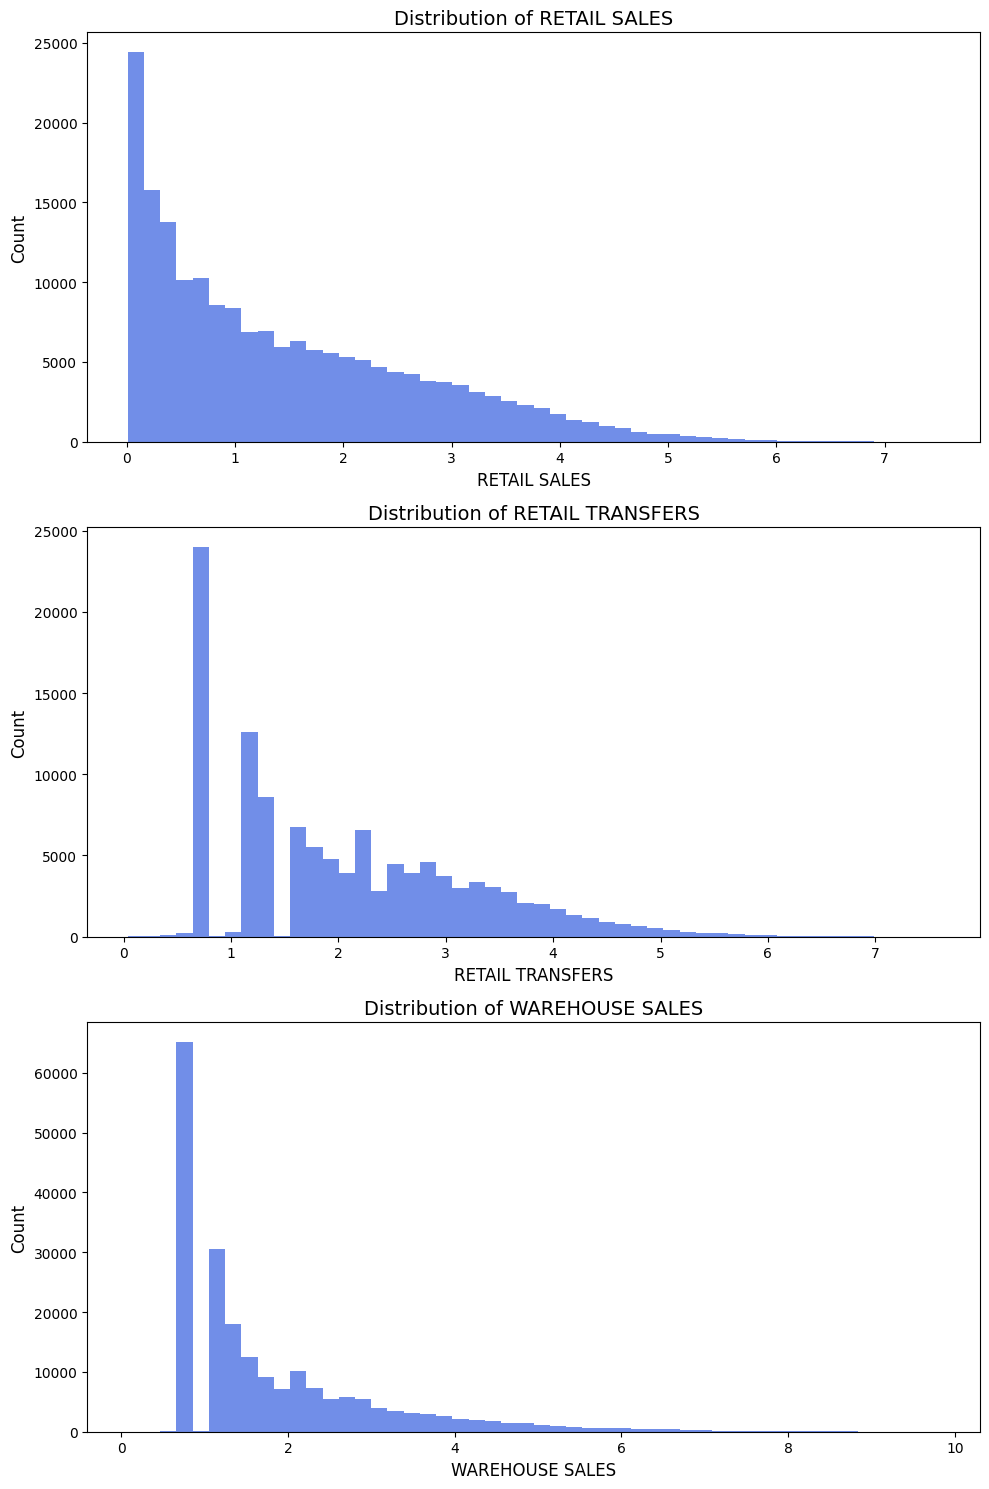

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sales_columns = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, col in enumerate(sales_columns):
    # Filter out zeros
    non_zero_data = warehouse_df_cleaned[warehouse_df_cleaned[col] > 0]
    
    log_data = np.log1p(non_zero_data[col])
    
    sns.histplot(log_data, bins=50, ax=axes[i], linewidth=0, color='royalblue')
    
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(f'{col}', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()


### __Retail Sales__
The distribution starts high on the left and gradually falls to the right. This shows that most retail sales transactions involve relatively small amounts, with frequency steadily decreasing as the sales volume increases. The long right tail confirms the presence of occasional high-value transactions, which is consistent with what we found in the descriptive statistics.

### __Retail Transfers__
This one looks slightly different from Retail Sales. The dip after the first bar and then a small rise again around the 1.0 to 1.5 range on the x-axis suggests that there may be two common clusters of transfer volumes — a very small transfer size and a moderate one. After that second cluster, the frequency drops off steadily. This could reflect two common types of transfer behavior in the warehouse operation.

### __Warehouse Sales__
This is the most heavily skewed of the three. The first bar is dramatically taller than everything else, meaning an overwhelming majority of non-zero warehouse sales are very small in volume. The distribution then drops sharply and falls into a very long right tail.


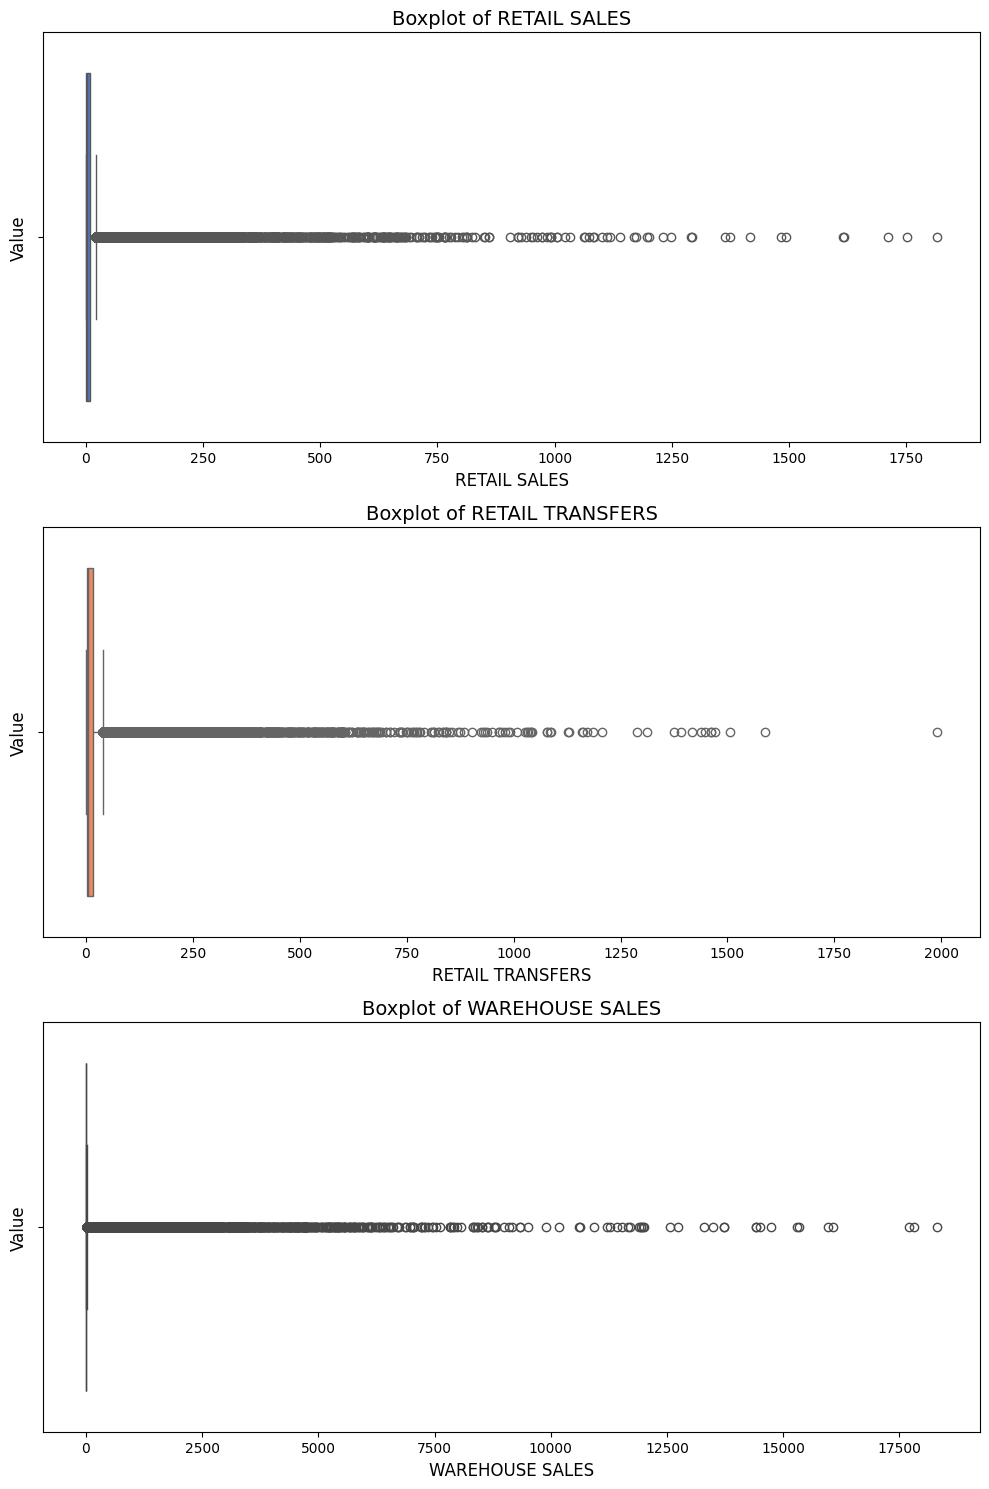

In [11]:
sales_columns = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']
# A different color assigned to each column
colors = ['royalblue', 'coral', 'mediumseagreen']
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for i, col in enumerate(sales_columns):
    # Filter out rows where the column value is less than or equal to zero
    positive_data = warehouse_df_cleaned[warehouse_df_cleaned[col] > 0]
    sns.boxplot(x=positive_data[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)
plt.tight_layout()
plt.show()

### __Findings__

The boxplots for all three sales columns display a similar pattern. The interquartile box is narrow and positioned close to zero in each case, indicating that the middle 50% of non-zero transactions are concentrated within a small range of low values. The median line sits near the lower end of the box in all three columns, which is consistent with the right skewness observed in the histograms.

A large number of outliers are visible as individual dots extending far beyond the upper whisker in each column. Retail Sales reaches a maximum of approximately 1,816, Retail Transfers extends to around 1,991, and Warehouse Sales shows the widest spread with values reaching up to 18,317. Despite being flagged as statistical outliers by the IQR method, these values represent legitimate high-volume transactions that are expected in a warehouse retail context and were therefore retained in the dataset.

Overall, the boxplots visually reinforce the conclusion drawn from the descriptive statistics — that while most transactions involve small amounts, a subset of large bulk transactions significantly extends the upper range of all three sales columns.

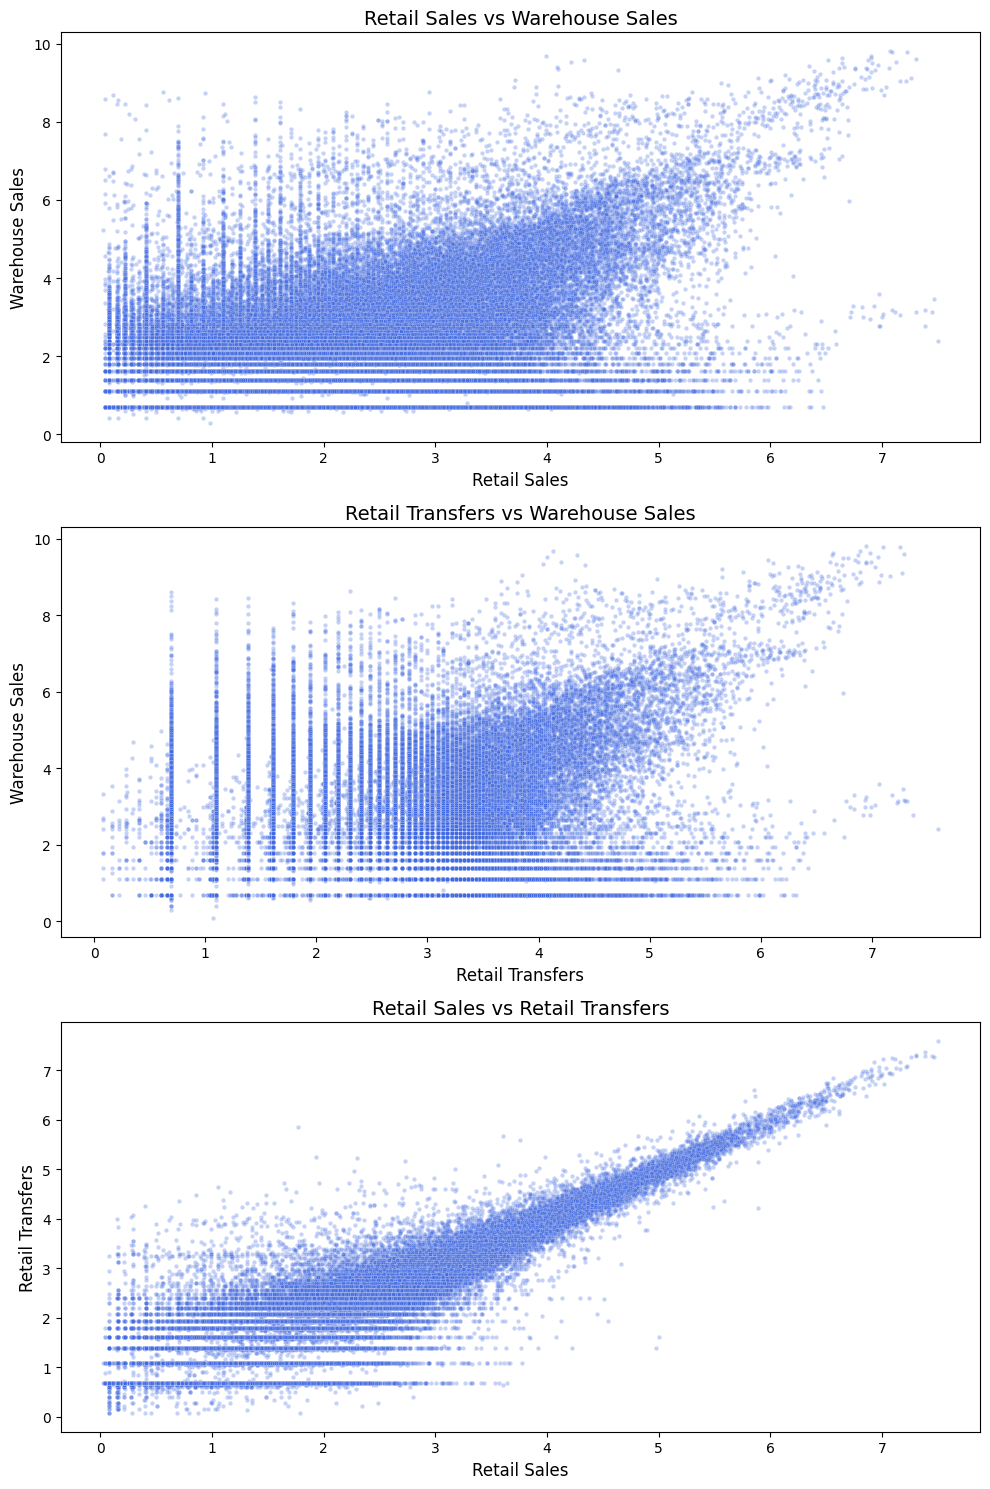

In [ ]:
# Define the variable pairs to plot
pairs = [
    ('RETAIL SALES', 'WAREHOUSE SALES'),
    ('RETAIL TRANSFERS', 'WAREHOUSE SALES'),
    ('RETAIL SALES', 'RETAIL TRANSFERS')
]
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for i, (x_col, y_col) in enumerate(pairs):
    # Filter out rows where either column is zero or less
    filtered_data = warehouse_df_cleaned[
        (warehouse_df_cleaned[x_col] > 0) & (warehouse_df_cleaned[y_col] > 0)
    ]
    # Apply log1p transformation to both columns
    log_x = np.log1p(filtered_data[x_col])
    log_y = np.log1p(filtered_data[y_col])
    sns.scatterplot(x=log_x, y=log_y, ax=axes[i], color='royalblue', alpha=0.3, s=10)

    x_label = x_col.title()
    y_label = y_col.title()
    
    axes[i].set_title(f'{x_label} vs {y_label}', fontsize=14)
    axes[i].set_xlabel(x_label, fontsize=12)
    axes[i].set_ylabel(y_label, fontsize=12)
plt.tight_layout()
plt.show()

### __Findings__

Scatter plots were used to explore the relationships between the three sales columns. Due to the heavily right-skewed nature of the data, a log transformation using log1p() was applied to both axes before plotting. This transformation compresses the wide range of values into a more readable scale, making the patterns between variables visible. Rows where either variable had a value of zero or less were excluded to ensure the log transformation produced valid results.

__Retail Sales vs Warehouse Sales__ shows a wide and dispersed cloud of points with no clear linear direction. This suggests a weak relationship between the two variables, meaning that higher retail sales do not consistently correspond to higher warehouse sales and vice versa.

__Retail Transfers vs Warehouse Sales__ displays a similar pattern of wide dispersion with no strong directional trend. The points are spread across the plot without forming a clear line, indicating that warehouse sales volume does not have a strong linear relationship with retail transfer activity.

__Retail Sales vs Retail Transfers__ stands out clearly from the other two. The points form a tight and consistent diagonal line moving from the bottom left to the upper right, which is a strong visual indicator of a positive linear relationship. This means that as retail sales increase, retail transfers tend to increase proportionally as well.

# C. Probability Distributions

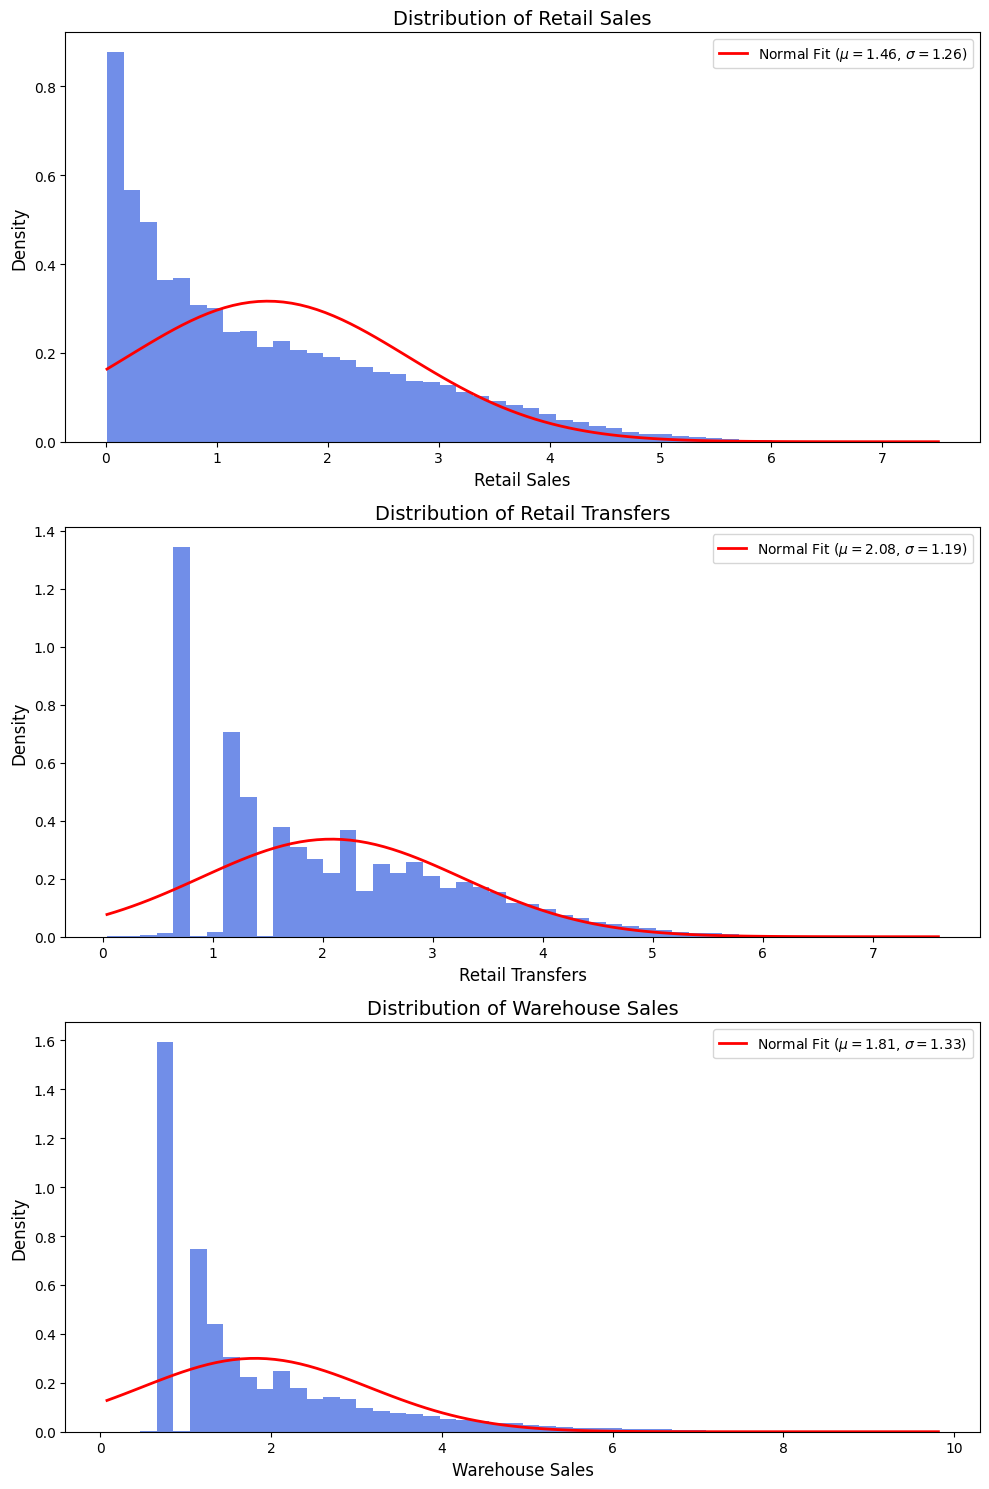

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

sales_columns = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

# Create a 3 row, 1 column layout
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, col in enumerate(sales_columns):
    # Filter out rows where the value is zero or less
    filtered_data = warehouse_df_cleaned[warehouse_df_cleaned[col] > 0][col]
    
    # Apply log1p transformation
    log_data = np.log1p(filtered_data)
    
    # Plot histogram with density scaling
    sns.histplot(log_data, stat='density', bins=50, color='royalblue', linewidth=0, ax=axes[i])
    
    # Fit a normal distribution to estimate mean and standard deviation
    mu, std = stats.norm.fit(log_data)
    
    # Generate x values for the PDF curve
    x = np.linspace(log_data.min(), log_data.max(), 100)
    # Calculate PDF values
    pdf = stats.norm.pdf(x, mu, std)
    
    # Added 'rf' prefix to make it a raw formatted string and avoid escape warnings
    axes[i].plot(x, pdf, color='red', linewidth=2, label=rf'Normal Fit ($\mu={mu:.2f}$, $\sigma={std:.2f}$)')
    
    # Format titles and labels in Title Case
    clean_name = col.title()
    axes[i].set_title(f'Distribution of {clean_name}', fontsize=14)
    axes[i].set_xlabel(clean_name, fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.show()

### __Findings__

To identify an appropriate probability distribution, a log transformation was applied to each sales column using log1p() to address the right skewness observed during exploratory data analysis. Zero and negative values were excluded prior to transformation. A normal distribution was then fitted to each log-transformed column using the mean and standard deviation estimated from the data, and the resulting probability density function was overlaid on each histogram.

The fitted normal curve for Retail Sales produced a mean of 1.46 and a standard deviation of 1.26. For Retail Transfers the mean was 2.08 with a standard deviation of 1.19, and for Warehouse Sales the mean was 1.81 with a standard deviation of 1.33.

While the normal curve provides a reasonable approximation, the histograms reveal that the actual distributions still exhibit some right skewness after transformation, particularly in Retail Transfers and Warehouse Sales. This indicates that the data follows an approximate log-normal distribution — meaning the raw values are right-skewed but their logarithms partially approximate a normal shape. The normal distribution was selected as the closest applicable distribution given the course context, with the understanding that the fit is approximate rather than exact.

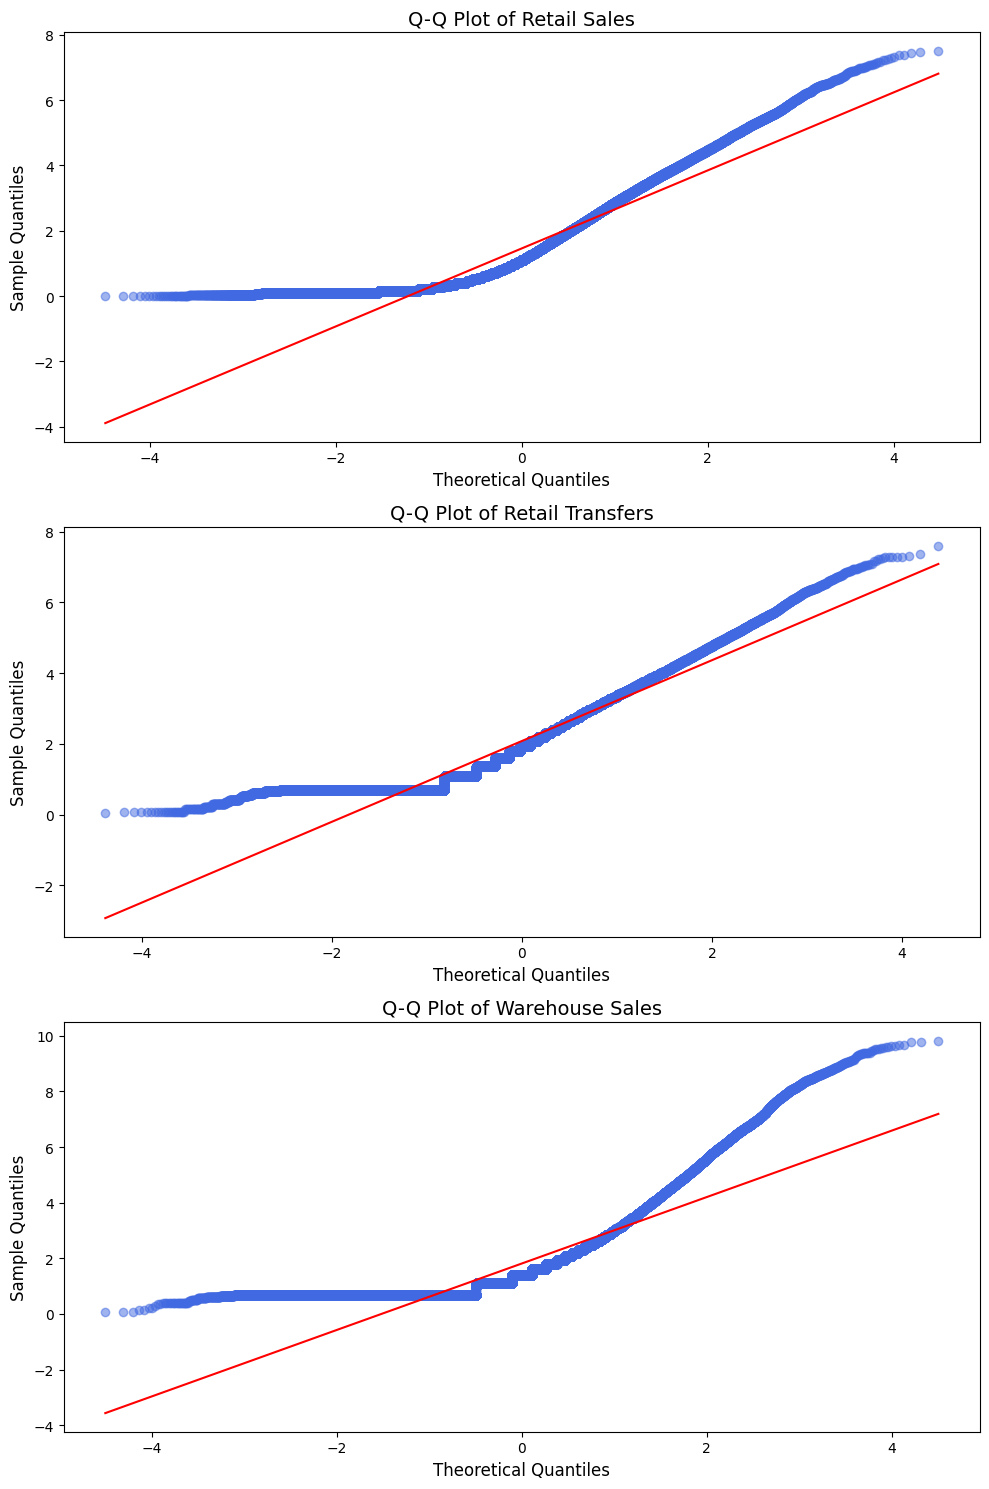

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

sales_columns = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

# Create a 3 row, 1 column layout
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, col in enumerate(sales_columns):
    # Filter out values that are zero or less (to safely apply log)
    filtered_data = warehouse_df_cleaned[warehouse_df_cleaned[col] > 0][col]
    
    # Apply log1p transformation
    log_data = np.log1p(filtered_data)
    
    # Generate Q-Q plot on the respective subplot axis
    stats.probplot(log_data, dist="norm", plot=axes[i])
    
    # Customize titles and labels
    clean_name = col.title()
    axes[i].set_title(f'Q-Q Plot of {clean_name}', fontsize=14)
    axes[i].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[i].set_ylabel('Sample Quantiles', fontsize=12)
    
    # Customize the scatter points and line colors to match your style (optional)
    axes[i].get_lines()[0].set_color('royalblue')
    axes[i].get_lines()[0].set_alpha(0.5)
    axes[i].get_lines()[1].set_color('red')

plt.tight_layout()
plt.show()

### __Findings__

The Q-Q plots compare the quantiles of the log-transformed data against the theoretical quantiles of a normal distribution. If the data were perfectly normal, all points would fall exactly along the red reference line.

In all three plots, the points follow the red line reasonably well in the middle section of the distribution, suggesting that the central portion of the data approximates a normal distribution after log transformation. However, noticeable deviations appear at both ends — particularly at the lower left where the points flatten out horizontally, and at the upper right where the points curve above the line. These deviations indicate the presence of heavy tails and confirm that the data is not perfectly normal.

Retail Sales shows the closest approximation to normality in the middle range, though the lower tail deviation is still evident. Retail Transfers displays a more irregular pattern in the middle section, which is consistent with the stepped appearance observed in its histogram. Warehouse Sales shows the most pronounced deviation at the upper tail, reflecting the influence of the large bulk transactions identified during exploratory data analysis.

# D. Application For Statistical Inference

### __Hypothesis Formulation__

This section tests whether there is a significant difference in average Warehouse Sales between Wine and Beer, the two most represented item types in the dataset.

__Null Hypothesis (H₀)__: There is no significant difference in the mean Warehouse Sales between Wine and Beer.

__Alternative Hypothesis (H₁)__: There is a significant difference in the mean Warehouse Sales between Wine and Beer.

An independent samples t-test was used to compare the means of the two groups. A significance level of 0.05 was applied, meaning a p-value below 0.05 would provide sufficient evidence to reject the null hypothesis.


In [19]:
# Performs Welch's independent t-test on WAREHOUSE SALES between WINE and BEER groups,
# and calculates their individual 95% confidence intervals.
from scipy import stats

wine_sales = warehouse_df_cleaned[warehouse_df_cleaned["ITEM TYPE"] == "WINE"]["WAREHOUSE SALES"]
beer_sales = warehouse_df_cleaned[warehouse_df_cleaned["ITEM TYPE"] == "BEER"]["WAREHOUSE SALES"]

t_statistic, p_value = stats.ttest_ind(wine_sales, beer_sales, equal_var=False)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}\n")

for name, data in [("WINE", wine_sales), ("BEER", beer_sales)]:
    n = len(data)
    mean = data.mean()
    sem = stats.sem(data)
    lower_bound, upper_bound = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
    print(f"{name:4} Mean: {mean:.4f} | 95% CI: [{lower_bound:.4f}, {upper_bound:.4f}]")

t-statistic: -46.9081
p-value: 0.0000

WINE Mean: 6.1662 | 95% CI: [6.0855, 6.2468]
BEER Mean: 153.9116 | 95% CI: [147.7387, 160.0845]


### __Findings__
The independent samples t-test produced a t-statistic of -46.9081 and a p-value of 0.0000. Since the p-value is far below the significance level of 0.05, the null hypothesis is rejected. This means there is a statistically significant difference in the mean Warehouse Sales between Wine and Beer.

The 95% confidence interval for Wine ranges from 6.0855 to 6.2468, while the confidence interval for Beer ranges from 147.7387 to 160.0845. The two intervals do not overlap, which further confirms that the difference between the two groups is both statistically and practically significant.

Beer shows a substantially higher mean Warehouse Sales of 153.91 compared to Wine at 6.17. This suggests that Beer generates considerably higher warehouse sales volume than Wine, which may reflect differences in bulk purchasing behavior or demand patterns between the two product categories.

# E. Regression Analysis
This section applies simple linear regression to examine the relationship between Retail Sales and Retail Transfers. Based on the scatter plot analysis conducted during exploratory data analysis, these two variables demonstrated the strongest linear relationship among the three sales columns. Retail Sales is used as the predictor variable and Retail Transfers as the outcome variable.


Slope: 0.8988
Intercept: 0.2633
R-squared: 0.8707
p-value: 0.0000


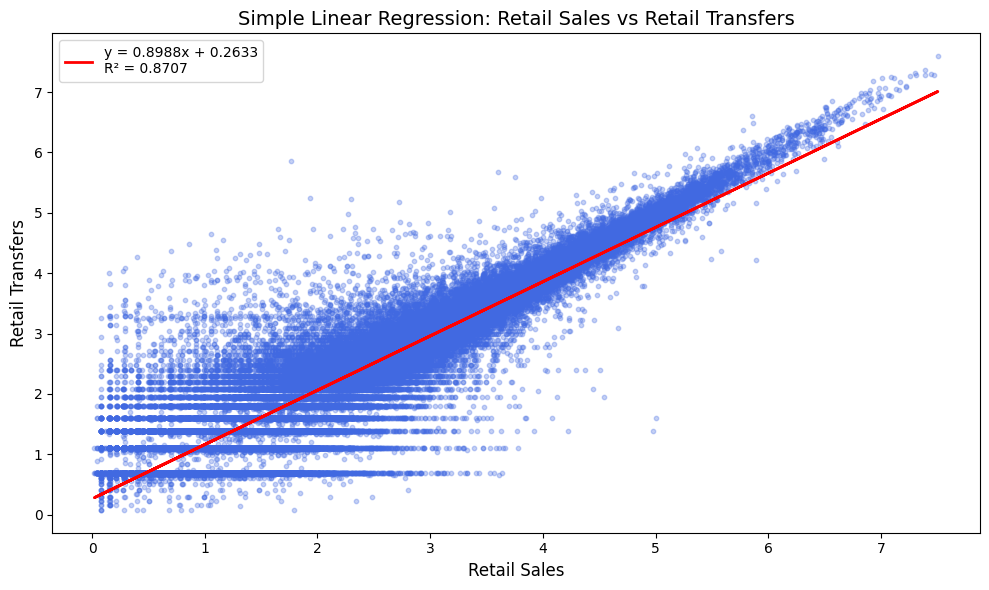

In [20]:
# Filters data, log-transforms Retail Sales and Retail Transfers, performs simple linear regression, 
# prints stats, and plots the scatter data with the fitted regression line.
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

regression_data = warehouse_df_cleaned[
    (warehouse_df_cleaned["RETAIL SALES"] > 0) & (warehouse_df_cleaned["RETAIL TRANSFERS"] > 0)
]

log_retail_sales = np.log1p(regression_data["RETAIL SALES"])
log_retail_transfers = np.log1p(regression_data["RETAIL TRANSFERS"])

slope, intercept, r_value, p_value, std_err = stats.linregress(log_retail_sales, log_retail_transfers)
r_squared = r_value ** 2

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"p-value: {p_value:.4f}")

regression_line = slope * log_retail_sales + intercept

plt.figure(figsize=(10, 6))
plt.scatter(log_retail_sales, log_retail_transfers, color="royalblue", alpha=0.3, s=10)
plt.plot(
    log_retail_sales, 
    regression_line, 
    color="red", 
    linewidth=2, 
    label=f"y = {slope:.4f}x + {intercept:.4f}\nR² = {r_squared:.4f}"
)

plt.title("Simple Linear Regression: Retail Sales vs Retail Transfers", fontsize=14)
plt.xlabel("Retail Sales", fontsize=12)
plt.ylabel("Retail Transfers", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### __Findings__

The simple linear regression model was fitted on log-transformed values of Retail Sales and Retail Transfers, excluding zero and negative values prior to transformation. The resulting regression equation is y = 0.8988x + 0.2633.

The slope of 0.8988 indicates that for every one unit increase in log-transformed Retail Sales, log-transformed Retail Transfers increases by approximately 0.8988 units. This near 1:1 relationship suggests that retail transfer activity closely mirrors retail sales volume.

The R² value of 0.8707 indicates that 87.07% of the variation in Retail Transfers is explained by Retail Sales. This represents a strong model fit, meaning Retail Sales is a highly reliable predictor of Retail Transfer activity. The p-value of 0.0000 confirms that this relationship is statistically significant and is not the result of random chance.

The scatter plot with the overlaid regression line visually confirms the strong positive linear relationship between the two variables, with data points clustering tightly around the red regression line across the entire range of values.